# Kaggle: Classify Leaves

The task is predicting categories of leaf images. This dataset contains 176 categories, 18353 training images, 8800 test images. Each category has at least 50 images for training. The test set is split evenly into the public and private leaderboard.

# 包导入

In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchsummary import summary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time

data_path = "../data"
out_path = "../out"

# 数据预览


#### 加载数据集 csv，查看样本以及标签数量

In [15]:
df = pd.read_csv(os.path.join(data_path, "train.csv"))

label_counts = df["label"].value_counts()

print("Training set shape:", df.shape, '\n')
print(df.head(), '\n')
print(label_counts, '\n')

Training set shape: (18353, 2) 

          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera 

label
maclura_pomifera            353
ulmus_rubra                 235
prunus_virginiana           223
acer_rubrum                 217
broussonettia_papyrifera    214
                           ... 
ulmus_procera                58
ailanthus_altissima          58
crataegus_crus-galli         54
evodia_daniellii             53
juniperus_virginiana         51
Name: count, Length: 176, dtype: int64 



#### 直方图可视化样本分布

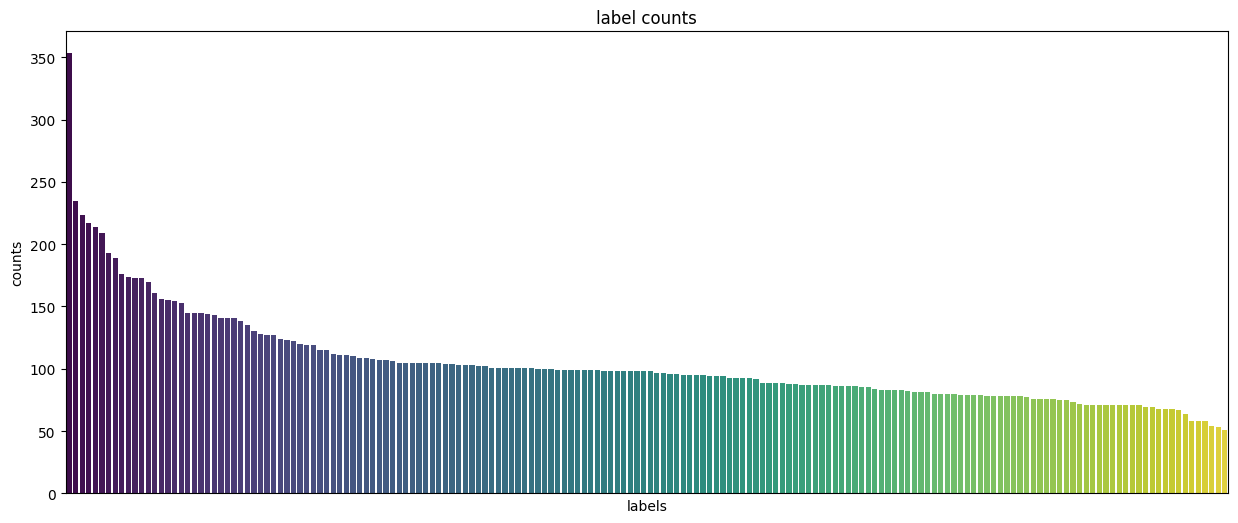

In [16]:
plt.figure(figsize=(15, 6))
sns.barplot(x=label_counts.index, y=label_counts.values,hue=label_counts.index, palette="viridis")
plt.xticks([])
plt.title('label counts')
plt.xlabel('labels')
plt.ylabel('counts')
plt.show()

# 加载训练所需数据

#### 使用 LabelEncode 对 label 进行编码，之后划分训练集和测试集

In [17]:
label_encoder = LabelEncoder()

df['label_idx'] = label_encoder.fit_transform(df['label'])
test_df = pd.read_csv(os.path.join(data_path, "test.csv"))
test_df['label_idx'] = -1       # 测试集没有标签，统一为 -1

train_df, val_df = train_test_split(
    df, 
    test_size=0.2,              # 20% 用于验证
    random_state=42, 
    stratify=df['label_idx']    # 保持标签分布一致
)

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)

Training set shape: (14682, 3)
Validation set shape: (3671, 3)


#### 定义 DataSet 类

In [18]:
class LeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(data_path, img_name)

        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label_idx']
        
        if self.transform:
            image = self.transform(image)

        return image, label

#### 定义图像预处理 transform

In [19]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # 调整图像大小
    transforms.ToTensor(),              # 转换为张量
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 标准化
])

# 带数据增强的 transform
augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.RandomVerticalFlip(),    # 随机垂直翻转
    transforms.RandomRotation(180),     # 随机旋转
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### 装载 DataLoader

In [20]:
batch_size = 64

train_ds = LeafDataset(train_df, transform=augmented_transform)
val_ds = LeafDataset(val_df, transform=base_transform)
test_ds = LeafDataset(test_df, transform=base_transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)

# 测试 DataLoader 是否工作正常
for images, labels in train_loader:
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    break
print(len(train_loader), "batches in training set")

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
230 batches in training set


# 加载模型

这里使用预训练的 ResNet 模型，为了使其适用于本次数据集，需要修改最后的全连接层的输出维度

经过一波训练后，加载训练得到的模型权重，继续微调

In [ ]:
model = models.resnet50(weights='DEFAULT')
num_ftrs = model.fc.in_features                                 # 获取最后一层全连接层的输入特征数
model.fc = nn.Linear(num_ftrs, len(label_encoder.classes_))     # 将输出类别数改为数据集中的类别数

model.load_state_dict(torch.load(os.path.join(out_path, 'best_model_95.pth')))   # 第一波训练后，加载最佳模型权重，进行微调

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("Model ready on device:", device)
print(summary(model, input_size=(3, 256, 256)))

Model ready on device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           9,408
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]           4,096
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]          16,384
      BatchNorm2d-12          [-1, 256, 64, 64]             512
           Conv2d-13          [-1, 256, 64, 64]          16,384
      Batch

# 定义损失函数与优化器

对于本树叶分类任务，采用：
- 损失函数: 交叉熵损失
- 优化器：Adam

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# 定义训练函数

将训练集中所有样本分批次输入模型，更新模型参数，最后返回本轮训练 loss 与准确率

In [10]:
def training_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in tqdm(dataloader, desc="Training", unit="batch"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)             # 前向传播
        loss = criterion(outputs, labels)   # 计算损失

        optimizer.zero_grad()               # 梯度清零
        loss.backward()                     # 反向传播
        optimizer.step()                    # 更新参数

        running_loss += loss.item() * images.size(0)
        _, predicts = outputs.max(1)        # 获取预测类别
        total += labels.size(0)
        correct += predicts.eq(labels).sum().item()
    
    epoch_loss = running_loss / total       # 本轮平均损失
    epoch_acc = 100 * correct / total       # 本轮准确率

    return epoch_loss, epoch_acc

# 定义验证函数

通过验证函数测试模型在没见过的验证集上的能力，返回验证集 loss 与准确率

In [11]:
def validate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicts = outputs.max(1)
            total += labels.size(0)
            correct += predicts.eq(labels).sum().item()
    
    val_loss = running_loss / total
    val_acc = 100 * correct / total

    return val_loss, val_acc

# 进行训练

先使用 1e-4 的学习率训练 20 轮，发现验证准确率在 95% 附近震荡，重新加载 95% 准确率的模型，改用 1e-5 的学习率再进行 10 轮训练

In [12]:
num_epochs = 10
best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = training_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start_time  # 计算本轮时间

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
          f"Time: {elapsed:.2f}s")

    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(out_path, 'best_model.pth'))

Training: 100%|██████████| 230/230 [01:45<00:00,  2.18batch/s]


Epoch [1/10] Train Loss: 0.0409, Train Acc: 98.54% | Val Loss: 0.1049, Val Acc: 96.10% | Time: 114.69s


Training: 100%|██████████| 230/230 [01:47<00:00,  2.13batch/s]


Epoch [2/10] Train Loss: 0.0301, Train Acc: 98.84% | Val Loss: 0.1064, Val Acc: 96.19% | Time: 116.69s


Training: 100%|██████████| 230/230 [01:48<00:00,  2.11batch/s]


...

Epoch [8/10] Train Loss: 0.0228, Train Acc: 98.99% | Val Loss: 0.0980, Val Acc: 96.54% | Time: 115.85s


Training: 100%|██████████| 230/230 [01:47<00:00,  2.14batch/s]


Epoch [9/10] Train Loss: 0.0220, Train Acc: 99.05% | Val Loss: 0.0935, Val Acc: 96.73% | Time: 117.10s


Training: 100%|██████████| 230/230 [01:46<00:00,  2.15batch/s]


Epoch [10/10] Train Loss: 0.0215, Train Acc: 99.05% | Val Loss: 0.0928, Val Acc: 96.38% | Time: 116.06s


#### 训练结果可视化

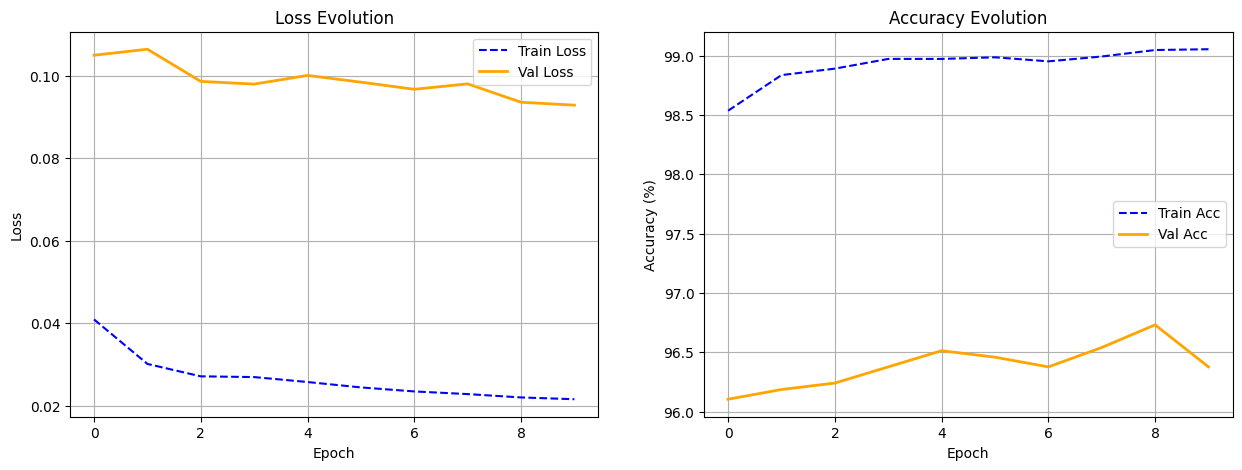

In [13]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # 绘制 Loss 曲线
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2)
    ax1.set_title('Loss Evolution')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # 绘制 Accuracy 曲线
    ax2.plot(history['train_acc'], label='Train Acc', color='blue', linestyle='--')
    ax2.plot(history['val_acc'], label='Val Acc', color='orange', linewidth=2)
    ax2.set_title('Accuracy Evolution')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_training_history(history)

#### 展示混淆矩阵

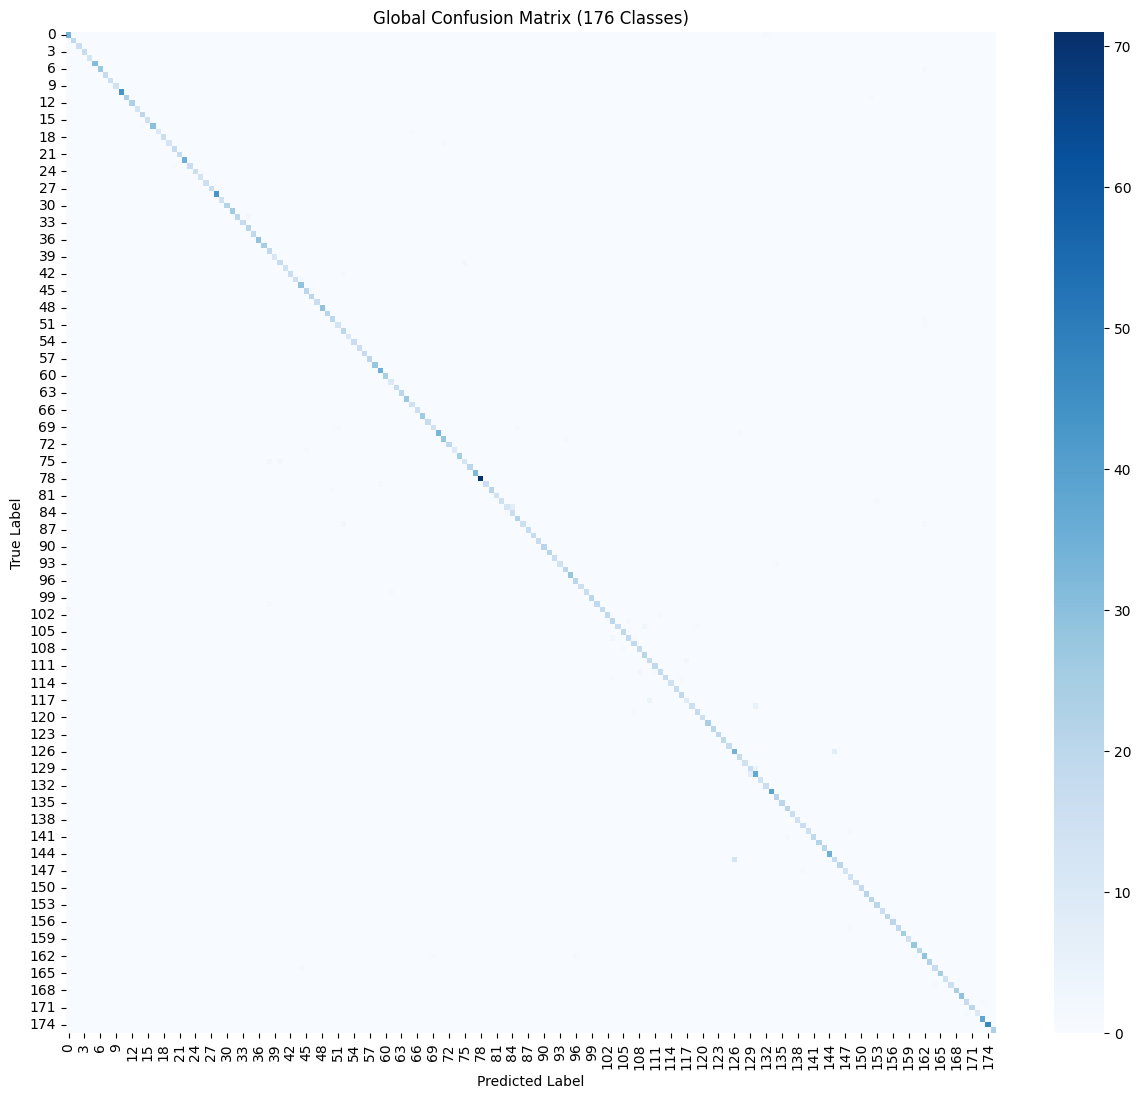

In [25]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)    # 计算混淆矩阵

plt.figure(figsize=(15, 13))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.title('Global Confusion Matrix (176 Classes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 进行预测

使用训练得到的 96.73% 准确率的模型对测试集进行预测

In [21]:
model.load_state_dict(torch.load(os.path.join(out_path, 'best_model_9673.pth')))
model.eval()

test_preds = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Predicting", unit="batch"):
        images = images.to(device)

        outputs = model(images)
        _, predicts = outputs.max(1)

        test_preds.extend(predicts.cpu().numpy())

# 将预测结果转换回标签
test_labels = label_encoder.inverse_transform(test_preds)
submission_df = pd.DataFrame({
    'image': test_df['image'],
    'label': test_labels
})

submission_df.to_csv(os.path.join(out_path, 'submission.csv'), index=False)
print("Submission file saved as " + os.path.join(out_path, 'submission.csv'))

Predicting: 100%|██████████| 138/138 [00:24<00:00,  5.67batch/s]

Submission file saved as ../out/submission.csv
